## Report

### 1. prediction table shape ✅
```
Models per ID: 1166 / 1166 / 1166 # each GSE has 1166 predictions.
``` 

### 2. max log2(prob/prior) dist ⚠️

||Human|Mouse|Note|
|--|--|--|--|
|mean max| ≈ 1.56|≈ 0.92|every GSE has a valid prediction & mouse prediction weaker than human prediction|
|min max| ≈ 0.0009||
|max < 1|1715 / 3395≈0.51|2809 / 4066≈0.69|many GSE metadata does not have a strong disease framing.|

### 3. anormalities ✅

```
mean > 1 : 0
std < 0.1 : 0
```

for each gse, there is no such:
* prob is high for all diseases
* prob is similar for all diseases

### 4. top gap = top 1 - top 2 ⚠️

||Human|Mouse|
|--|--|--|
|median gap| ≈ 0.05|≈ 0.045|
|gap < 0.1|2263|2927|

-> for most gse, top 1 and top 2 predictions are almost the same.
    - argmax unstable
    - top 1 highly uncertain

### Conclusion: focus on strong signal GSE only

* log2(prob/prior) > 1
* 且 gap > 0.2 ?

### 5. stable top 1 prediction w/ diff corpus（≈85%）

## Code
### generate top1

In [18]:
import pandas as pd

def all_to_one(fp, output):
    df = pd.read_csv(fp)
    df["mondo_id"] = df["model"].str.replace("__preds", "", regex=False)

    n_ids = df["ID"].nunique()
    models_per_id = df.groupby("ID")["mondo_id"].nunique()
    print("IDs:", n_ids)
    print("Models per ID (min/median/max):",
          int(models_per_id.min()),
          float(models_per_id.median()),
          int(models_per_id.max()))

    df = df.sort_values(["ID", "log2(prob/prior)", "prob", "mondo_id"],
                        ascending=[True, False, False, True],
                        kind="mergesort")
    top1 = df.groupby("ID", as_index=False).head(1)[
        ["ID", "mondo_id", "prob", "log2(prob/prior)", "related_words"]
    ].reset_index(drop=True)

    top1.to_csv(output, index=False)
    print("Saved:", output)

all_to_one("results/meta/human_title_summary_preds.csv", "results/top1/human_title_summary_preds.csv")
all_to_one("results/meta/human_title_summary_design_preds.csv", "results/top1/human_title_summary_design_preds.csv")
all_to_one("results/meta/mouse_title_summary_preds.csv", "results/top1/mouse_title_summary_preds.csv")
all_to_one("results/meta/mouse_title_summary_design_preds.csv", "results/top1/mouse_title_summary_design_preds.csv")

IDs: 3395
Models per ID (min/median/max): 1166 1166.0 1166
Saved: results/top1/human_title_summary_preds.csv
IDs: 3395
Models per ID (min/median/max): 1166 1166.0 1166
Saved: results/top1/human_title_summary_design_preds.csv
IDs: 4066
Models per ID (min/median/max): 1166 1166.0 1166
Saved: results/top1/mouse_title_summary_preds.csv
IDs: 4066
Models per ID (min/median/max): 1166 1166.0 1166
Saved: results/top1/mouse_title_summary_design_preds.csv


### all model

Human rows: (3958570, 6)
Mouse rows: (4740956, 6)

--- Human ---
IDs: 3395
Models per ID (min/median/max): 1166 1166.0 1166

--- Mouse ---
IDs: 4066
Models per ID (min/median/max): 1166 1166.0 1166

--- Human distribution ---
Max log2 mean: 1.5618509075861153
Max log2 min: 0.0008938698145071
Max log2 max: 6.736767467849661
IDs where max < 0: 0
IDs where max < 1: 1715

--- Mouse distribution ---
Max log2 mean: 0.9239166800047055
Max log2 min: 0.0008938698145071
Max log2 max: 5.562013940584957
IDs where max < 0: 0
IDs where max < 1: 2809

--- Human anomaly check ---
IDs with mean > 1: 0
IDs with std < 0.1: 0

--- Mouse anomaly check ---
IDs with mean > 1: 0
IDs with std < 0.1: 0


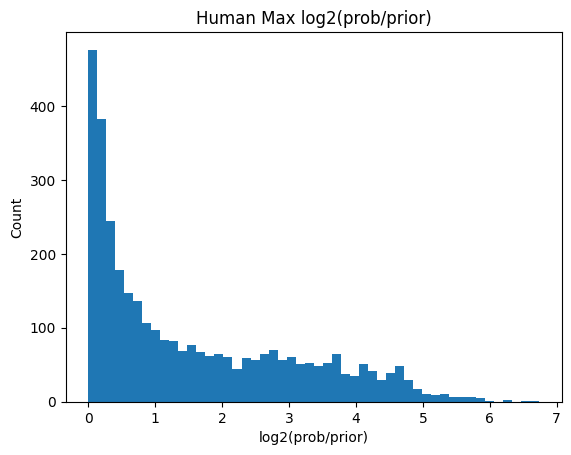

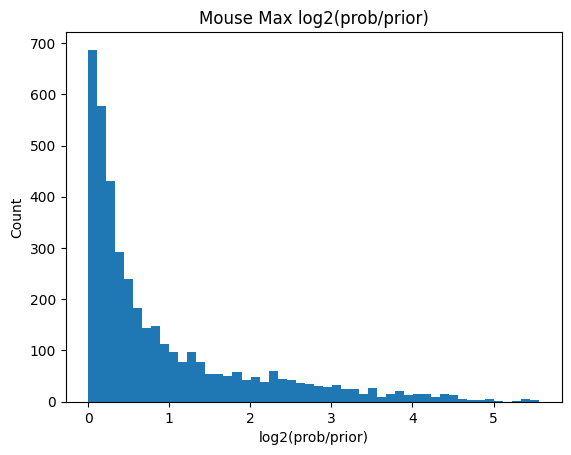


--- Human top gap ---
Mean gap: 0.10952153581069268
Median gap: 0.05048228103715857
IDs with gap < 0.1: 2263

--- Mouse top gap ---
Mean gap: 0.09224398137809624
Median gap: 0.0453929071715595
IDs with gap < 0.1: 2927


In [19]:
import pandas as pd
import numpy as np

def load_preds(fp):
    df = pd.read_csv(fp)
    df["mondo_id"] = df["model"].str.replace("__preds", "", regex=False)
    return df

human_preds = load_preds("results/meta/human_title_summary_preds.csv")
mouse_preds = load_preds("results/meta/mouse_title_summary_preds.csv")

print("Human rows:", human_preds.shape)
print("Mouse rows:", mouse_preds.shape)

def check_models_per_id(df, name):
    print(f"\n--- {name} ---")
    models_per_id = df.groupby("ID")["mondo_id"].nunique()
    print("IDs:", df["ID"].nunique())
    print("Models per ID (min/median/max):",
          int(models_per_id.min()),
          float(models_per_id.median()),
          int(models_per_id.max()))
    
    if models_per_id.min() != models_per_id.max():
        print("⚠ Some IDs missing models")

check_models_per_id(human_preds, "Human")
check_models_per_id(mouse_preds, "Mouse")

def distribution_check(df, name):
    print(f"\n--- {name} distribution ---")
    
    stats = df.groupby("ID")["log2(prob/prior)"].agg(["max", "mean", "std"])
    
    print("Max log2 mean:", stats["max"].mean())
    print("Max log2 min:", stats["max"].min())
    print("Max log2 max:", stats["max"].max())
    
    print("IDs where max < 0:", (stats["max"] < 0).sum())
    print("IDs where max < 1:", (stats["max"] < 1).sum())

distribution_check(human_preds, "Human")
distribution_check(mouse_preds, "Mouse")

def anomaly_check(df, name):
    print(f"\n--- {name} anomaly check ---")
    
    stats = df.groupby("ID")["log2(prob/prior)"].agg(["mean", "std"])
    
    print("IDs with mean > 1:", (stats["mean"] > 1).sum())
    print("IDs with std < 0.1:", (stats["std"] < 0.1).sum())

anomaly_check(human_preds, "Human")
anomaly_check(mouse_preds, "Mouse")

import matplotlib.pyplot as plt

def plot_max_distribution(df, name):
    max_scores = df.groupby("ID")["log2(prob/prior)"].max()
    
    plt.hist(max_scores, bins=50)
    plt.title(f"{name} Max log2(prob/prior)")
    plt.xlabel("log2(prob/prior)")
    plt.ylabel("Count")
    plt.show()

plot_max_distribution(human_preds, "Human")
plot_max_distribution(mouse_preds, "Mouse")

def top_gap_check(df, name):
    print(f"\n--- {name} top gap ---")
    
    df_sorted = df.sort_values(["ID", "log2(prob/prior)"], ascending=[True, False])
    top2 = df_sorted.groupby("ID").head(2)
    
    gap = top2.groupby("ID")["log2(prob/prior)"].diff().abs()
    gap = gap.dropna()
    
    print("Mean gap:", gap.mean())
    print("Median gap:", gap.median())
    print("IDs with gap < 0.1:", (gap < 0.1).sum())

top_gap_check(human_preds, "Human")
top_gap_check(mouse_preds, "Mouse")

### filter & compare corpus

In [20]:
human_ts  = pd.read_csv("results/top1/human_title_summary_preds.csv")
human_tsd = pd.read_csv("results/top1/human_title_summary_design_preds.csv")
mouse_ts  = pd.read_csv("results/top1/mouse_title_summary_preds.csv")
mouse_tsd = pd.read_csv("results/top1/mouse_title_summary_design_preds.csv")

def filter_strong_top1(df, threshold=1.5):
    return df[df["log2(prob/prior)"] > threshold].copy()

def compare_top1_strong_intersection(ts, tsd, name, threshold=1.5):
    ts_s  = filter_strong_top1(ts, threshold)
    tsd_s = filter_strong_top1(tsd, threshold)

    merged = ts_s.merge(tsd_s, on="ID", suffixes=("_ts", "_tsd"))
    total = len(merged)
    same = (merged["mondo_id_ts"] == merged["mondo_id_tsd"]).sum()

    print(f"\n--- {name} strong intersection (threshold={threshold}) ---")
    print("Strong TS:", len(ts_s))
    print("Strong TSD:", len(tsd_s))
    print("Intersection:", total)
    if total > 0:
        print("Same top1:", same)
        print("Agreement rate:", same / total)
    else:
        print("No IDs in intersection (threshold too strict?)")

compare_top1_strong_intersection(human_ts, human_tsd, "Human", threshold=1.5)
compare_top1_strong_intersection(mouse_ts, mouse_tsd, "Mouse", threshold=1.5)

def compare_scores_strong_intersection(ts, tsd, name, threshold=1.5):
    ts_s  = filter_strong_top1(ts, threshold)
    tsd_s = filter_strong_top1(tsd, threshold)

    merged = ts_s.merge(tsd_s, on="ID", suffixes=("_ts", "_tsd"))
    if len(merged) == 0:
        print(f"\n--- {name} ---\nNo IDs in intersection.")
        return

    diff = merged["log2(prob/prior)_tsd"] - merged["log2(prob/prior)_ts"]
    print(f"\n--- {name} score diff on strong intersection (threshold={threshold}) ---")
    print("Mean diff:", diff.mean())
    print("Median diff:", diff.median())
    print("Increased:", (diff > 0).sum())
    print("Decreased:", (diff < 0).sum())

compare_scores_strong_intersection(human_ts, human_tsd, "Human", threshold=1.5)
compare_scores_strong_intersection(mouse_ts, mouse_tsd, "Mouse", threshold=1.5)


--- Human strong intersection (threshold=1.5) ---
Strong TS: 1388
Strong TSD: 1389
Intersection: 1290
Same top1: 1085
Agreement rate: 0.8410852713178295

--- Mouse strong intersection (threshold=1.5) ---
Strong TS: 880
Strong TSD: 879
Intersection: 797
Same top1: 677
Agreement rate: 0.849435382685069

--- Human score diff on strong intersection (threshold=1.5) ---
Mean diff: -0.017015329112033954
Median diff: -0.023693257574558202
Increased: 593
Decreased: 697

--- Mouse score diff on strong intersection (threshold=1.5) ---
Mean diff: -0.05362198615163828
Median diff: -0.05341180079309016
Increased: 325
Decreased: 472


In [22]:
threshold = 1

human_final = human_ts[human_ts["log2(prob/prior)"] > threshold]
mouse_final = mouse_ts[mouse_ts["log2(prob/prior)"] > threshold]

human_final.to_csv("results/human_strong_preds.csv", index=False)
mouse_final.to_csv("results/mouse_strong_preds.csv", index=False)

print("Human saved:", human_final.shape)
print("Mouse saved:", mouse_final.shape)

Human saved: (1680, 5)
Mouse saved: (1257, 5)
